# **Mod_5 Assignment 1**

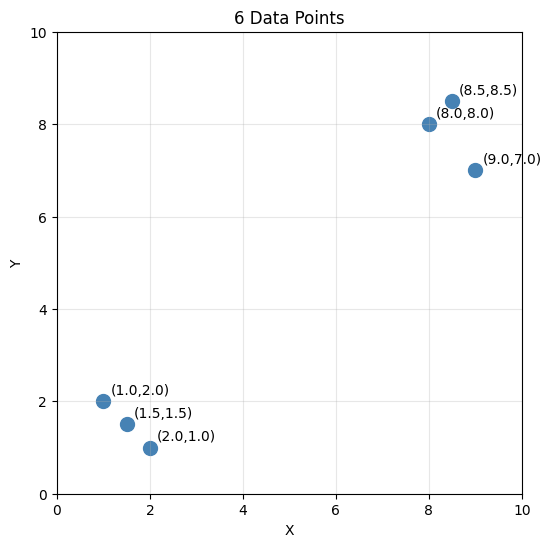

In [1]:
# Task 1 - Step 1 and 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

points = np.array([[1, 2], [2, 1], [1.5, 1.5], [8, 8], [9, 7], [8.5, 8.5]])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=100, color='steelblue')
for x, y in points:
    plt.annotate(f'({x},{y})', (x, y), textcoords="offset points", xytext=(5, 5))
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.title('6 Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.show()

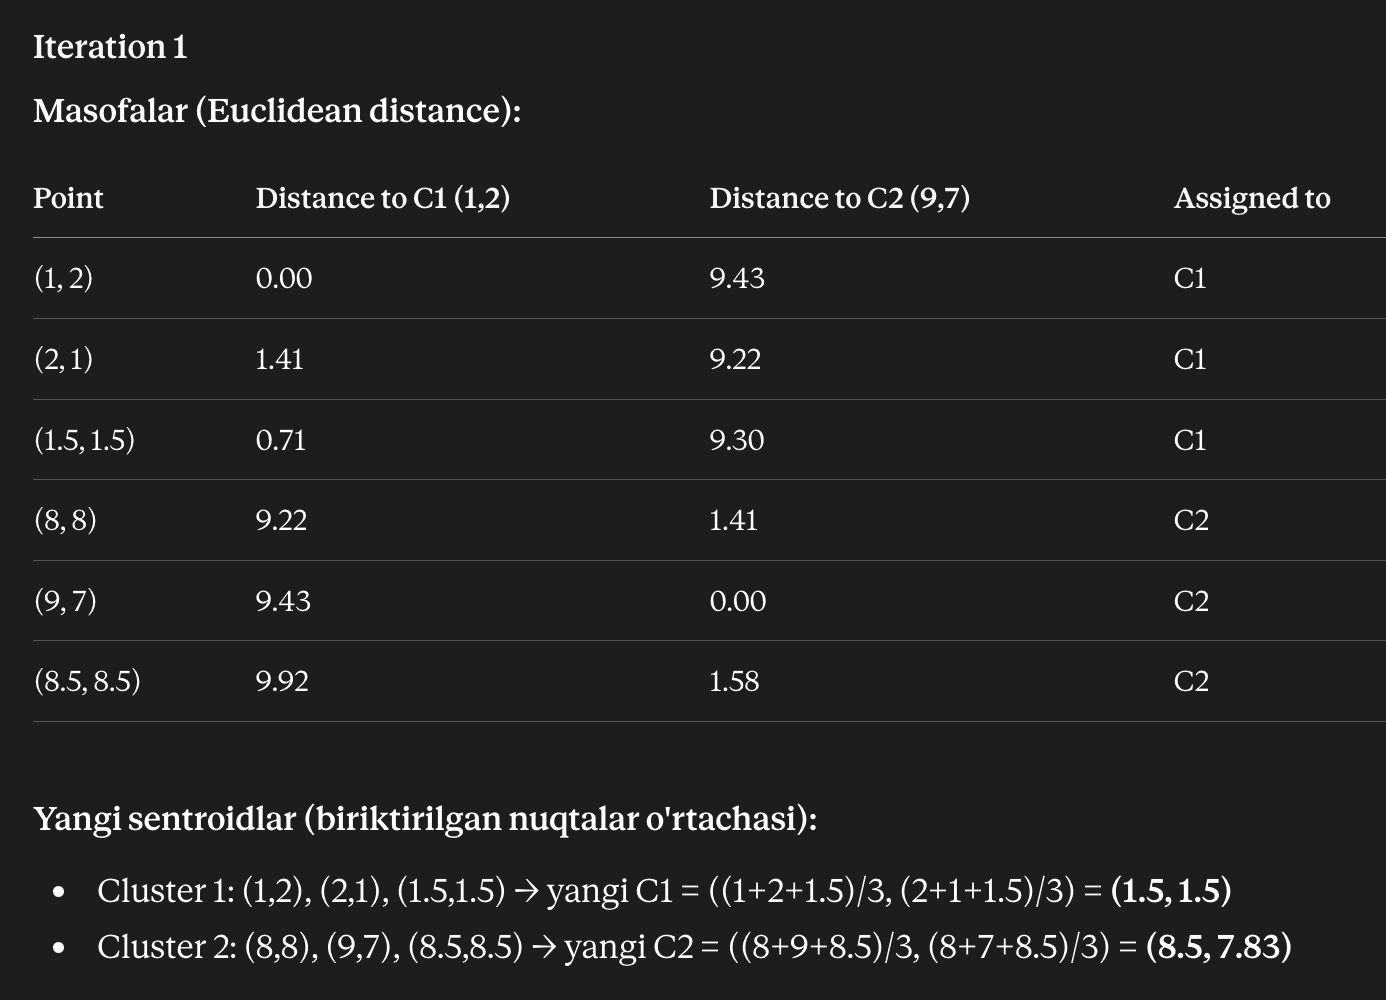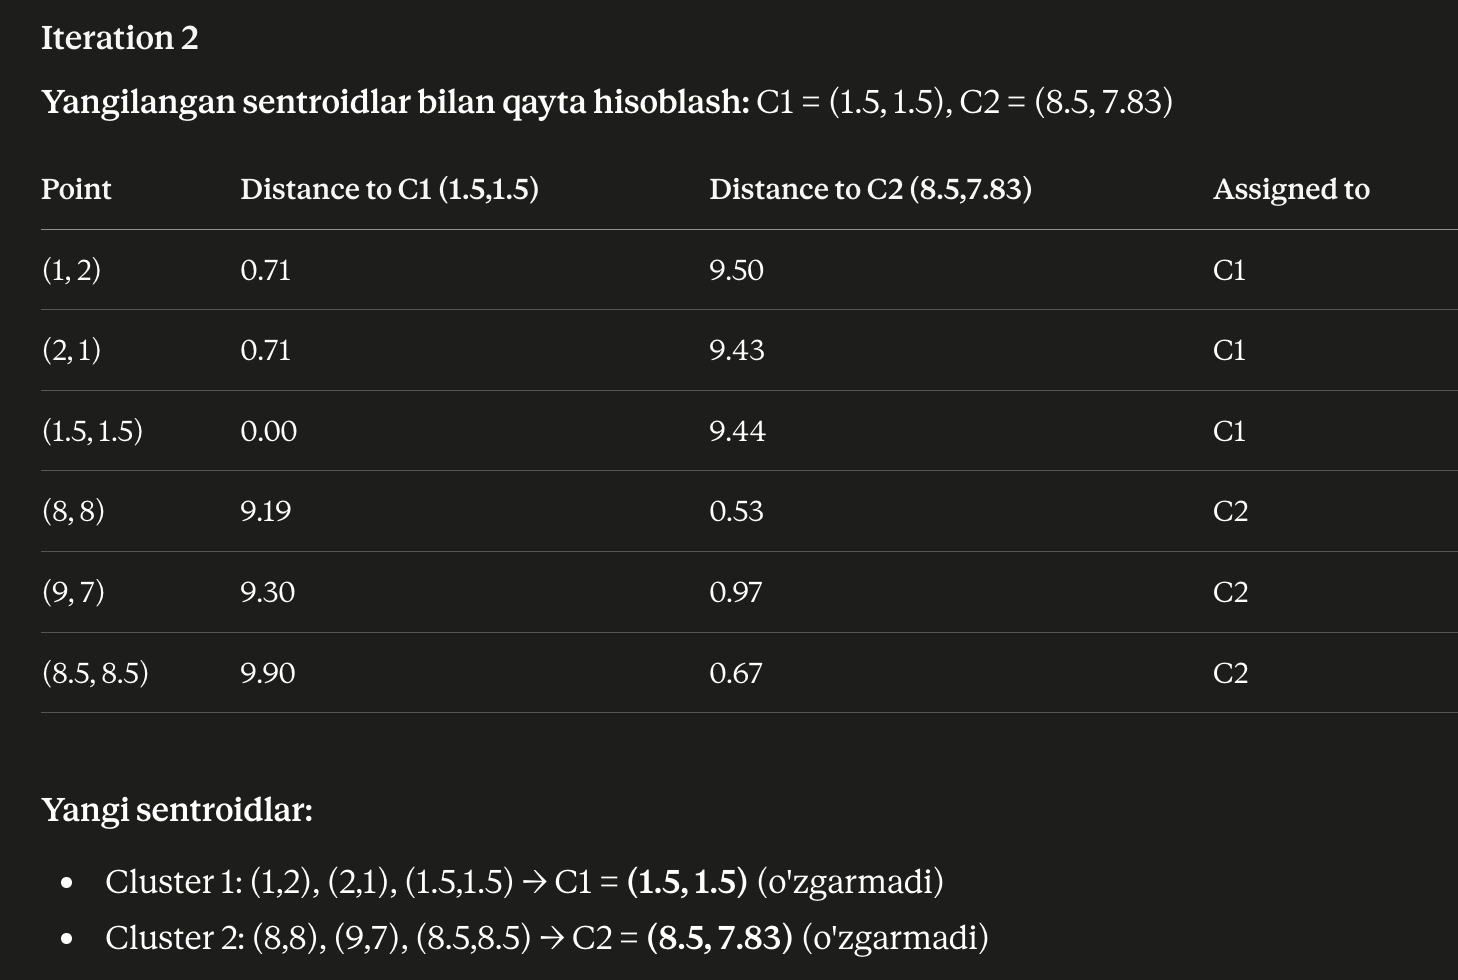

In [2]:
# Task 3 - Step 1, 2 and 3
X = np.array([[1, 2], [2, 1], [1.5, 1.5], [8, 8], [9, 7], [8.5, 8.5]])

kmeans = KMeans(n_clusters=2, init=np.array([[1, 2], [9, 7]]), n_init=1, random_state=42)
labels = kmeans.fit_predict(X)

print('Cluster assignments:', labels)
print('Final centroids:', kmeans.cluster_centers_)

Cluster assignments: [0 0 0 1 1 1]
Final centroids: [[1.5        1.5       ]
 [8.5        7.83333333]]


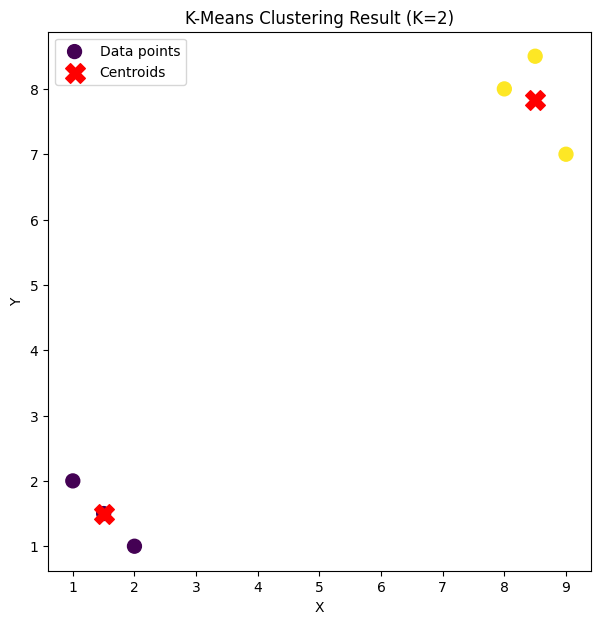

In [3]:
# Task 4 - Step 1, 2 and 3
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, label='Data points')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('K-Means Clustering Result (K=2)')
plt.legend()
plt.show()

# **Mod_5 Assignment 2**

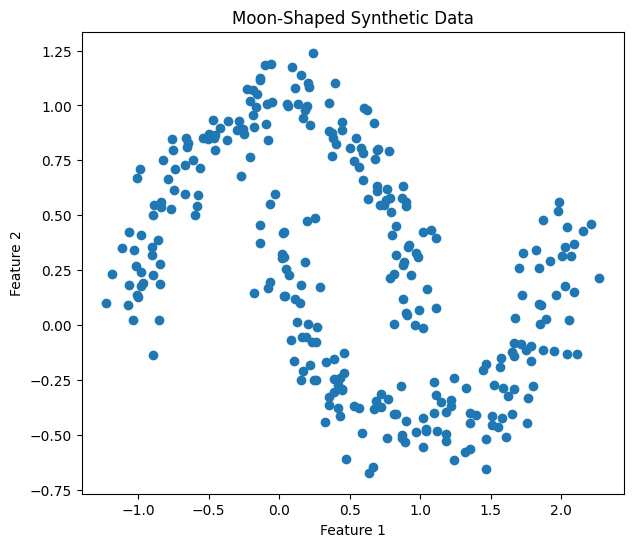

In [4]:
# Task 1 - Step 1 and 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-Shaped Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

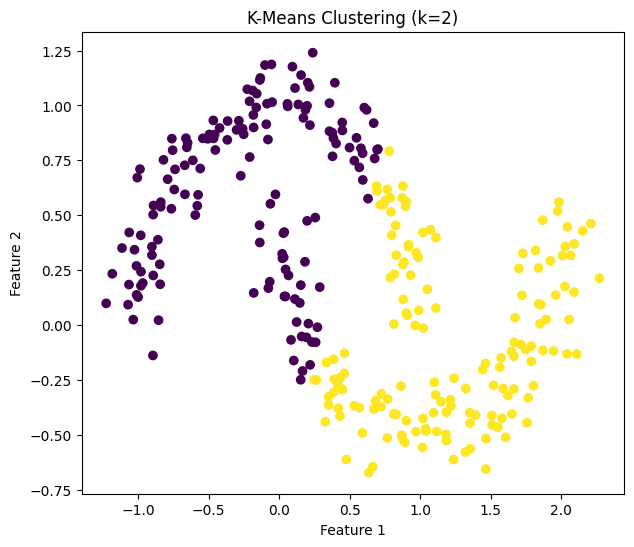

In [5]:
# Task 2 - Step 1 and 2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('K-Means Clustering (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

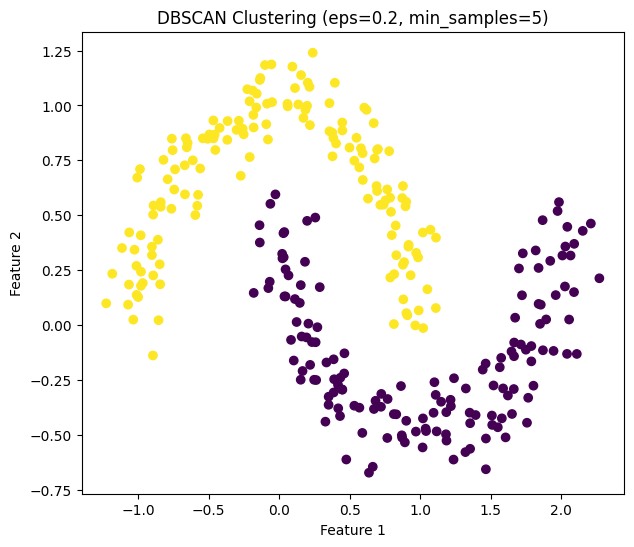

In [6]:
# Task 3 - Step 1 and 2
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X)

plt.figure(figsize=(7, 6))
colors = np.array(['gray' if l == -1 else plt.cm.viridis(l / max(labels_db.max(), 1)) for l in labels_db])
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title('DBSCAN Clustering (eps=0.2, min_samples=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

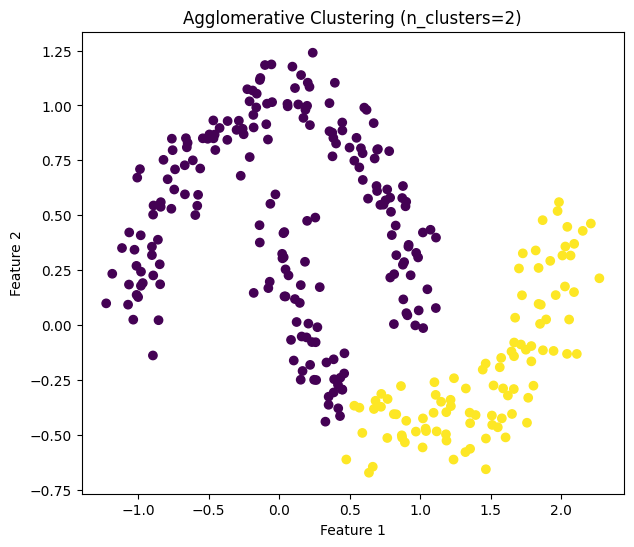

In [7]:
# Task 5 (Bonus)
agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='viridis')
plt.title('Agglomerative Clustering (n_clusters=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# **Mod_5 Assignment 3**

In [8]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

url = 'https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv'
df = pd.read_csv(url)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

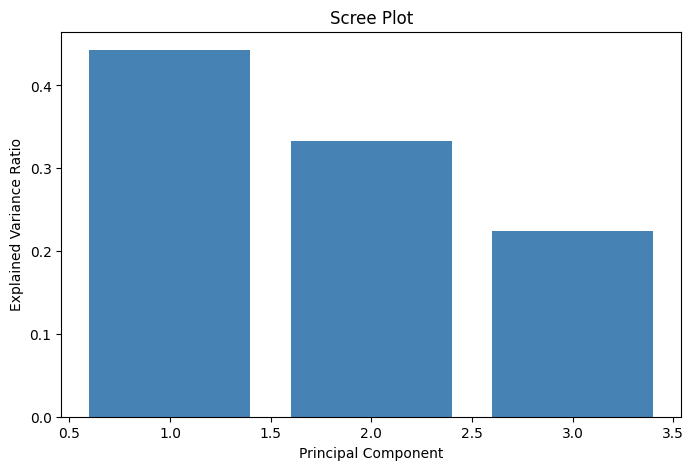

In [9]:
# Task 1 - Step 1, 2 and 3
pca = PCA(n_components=None, random_state=42)
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

In [10]:
# Task 1 - Step 4
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print('Cumulative explained variance:', cumulative_variance.round(4))
print('Components for 90% variance:', np.argmax(cumulative_variance >= 0.90) + 1)
print('Components for 95% variance:', np.argmax(cumulative_variance >= 0.95) + 1)

Cumulative explained variance: [0.4427 0.7757 1.    ]
Components for 90% variance: 3
Components for 95% variance: 3


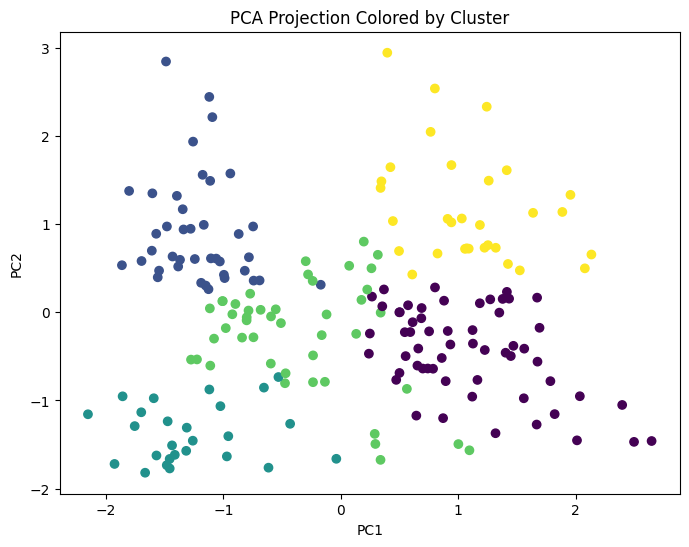

In [11]:
# Task 2 - Step 1 and 2
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Cluster')
plt.show()

In [12]:
# Task 3 - Step 1
loadings = pd.DataFrame(pca_2d.components_, columns=features, index=['PC1', 'PC2'])
loadings

,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.706382,-0.048024,-0.706199
PC2,0.030141,0.998832,-0.037775
